In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.spectra import sensor_spectra
from src.ComplexDemodTest import complex_demod_hourly, complex_demod_forced
from src.bulk_parameters import compute_H0, Hs_band

In [2]:
# set time window
ti = pd.Timestamp("2008-01-13 18:00:00")
tf = pd.Timestamp("2008-01-14 06:00:00")

In [3]:
# ---- load data ----- #
df1 = pd.read_parquet('../data_interim/df1.parquet')
df6 = pd.read_parquet('../data_interim/df6.parquet')

# take spectra
S1 = sensor_spectra(df1, nperseg = 1024)
S6 = sensor_spectra(df6, nperseg = 1024)

# compute sig wave heights
H0 = compute_H0(S6)

IG = (0.004, 0.04)  
SS = (0.041, 0.20) 
Hs_ig = Hs_band(S1,IG[0], IG[1])
Hs_ss = Hs_band(S1, SS[0], SS[1])


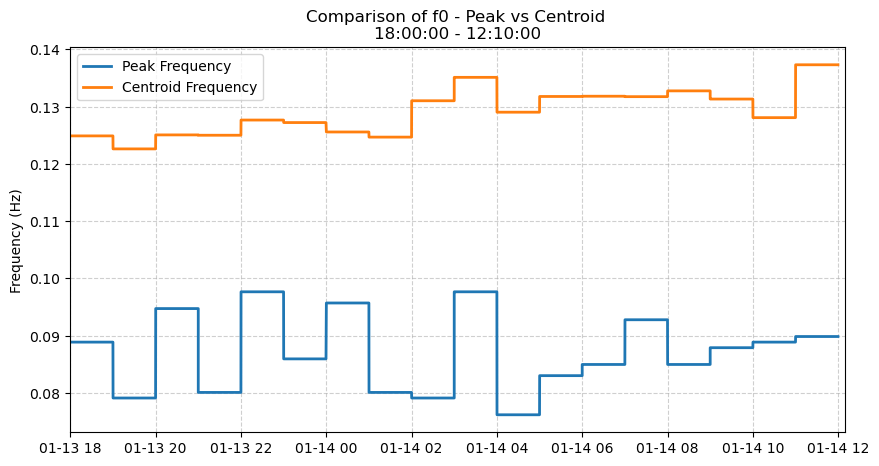

In [4]:


# Full analysis time range
ti = pd.Timestamp("2008-01-13 18:00:00")
tf = pd.Timestamp("2008-01-14 12:00:00")

# The specific short window to zoom in on
zoom_start = pd.Timestamp("2008-01-13 18:00:00")
zoom_end   = pd.Timestamp("2008-01-14 12:10:00")

SS = (0.05, 0.25)

# ---- 1. Run Complex Demodulation (Peak Method) ---- #
# df_peak will have the same index as the original data (e.g., 1Hz or 2Hz)
# The 'f0' column will be constant for 1-hour blocks
df_peak = complex_demod_hourly(
    df1, ti, tf, p_col="h", f_swell=SS, f0_method='peak'
)

# ---- 2. Run Complex Demodulation (Centroid Method) ---- #
df_cent = complex_demod_hourly(
    df1, ti, tf, p_col="h", f_swell=SS, f0_method='centroid'
)

# ---- 3. Plotting Raw Data (No Resampling) ---- #
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the raw f0 series. 
# Since these are from 'complex_demod_hourly', they will look like steps.
ax.plot(df_peak.index, df_peak['f0'], label='Peak Frequency', color='tab:blue', linewidth=2)
ax.plot(df_cent.index, df_cent['f0'], label='Centroid Frequency', color='tab:orange', linewidth=2)

# Zoom in on the 15-minute window
ax.set_xlim(zoom_start, zoom_end)

# Formatting
ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Comparison of f0 - Peak vs Centroid \n{zoom_start.time()} - {zoom_end.time()}')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()


I'm interested to understand the difference between the peak and centroid freq for CD. Does the spread of the two have a physical meaning? Is one more robust than the other? does it depend on applicartion? Am i asking too many questions? do i need a sandwich?

Using offshore carrier frequencies (0.04-0.20Hz) to compare the two methods. I will run CD on the same data using both methods and then plot them together to see how they differ over time. I will also look at the spread between the two frequencies to see if it has any physical meaning or if one method is more stable than the other.

In [5]:
# ---- Configuration ---- #
ti = pd.Timestamp("2008-01-13 18:00:00")
tf = pd.Timestamp("2008-01-14 06:00:00")

# Run Offshore (Sensor 6)
df6_peak = complex_demod_hourly(df6, ti, tf, p_col="h", f_swell=SS, f0_method='peak')
df6_cent = complex_demod_hourly(df6, ti, tf, p_col="h", f_swell=SS, f0_method='centroid')

# Run Nearshore (Sensor 1)
df1_peak = complex_demod_hourly(df1, ti, tf, p_col="h", f_swell=SS, f0_method='peak')
df1_cent = complex_demod_hourly(df1, ti, tf, p_col="h", f_swell=SS, f0_method='centroid')

# create a summary df
# We resample to 1H to get a clean table of the hourly schedules
# (Since f0 is constant per hour, mean() just grabs that value)
f0_schedule = pd.DataFrame({
    'Offshore_Peak': df6_peak['f0'],
    'Offshore_Centroid': df6_cent['f0'],
    'Nearshore_Peak': df1_peak['f0'],
    'Nearshore_Centroid': df1_cent['f0'],
})

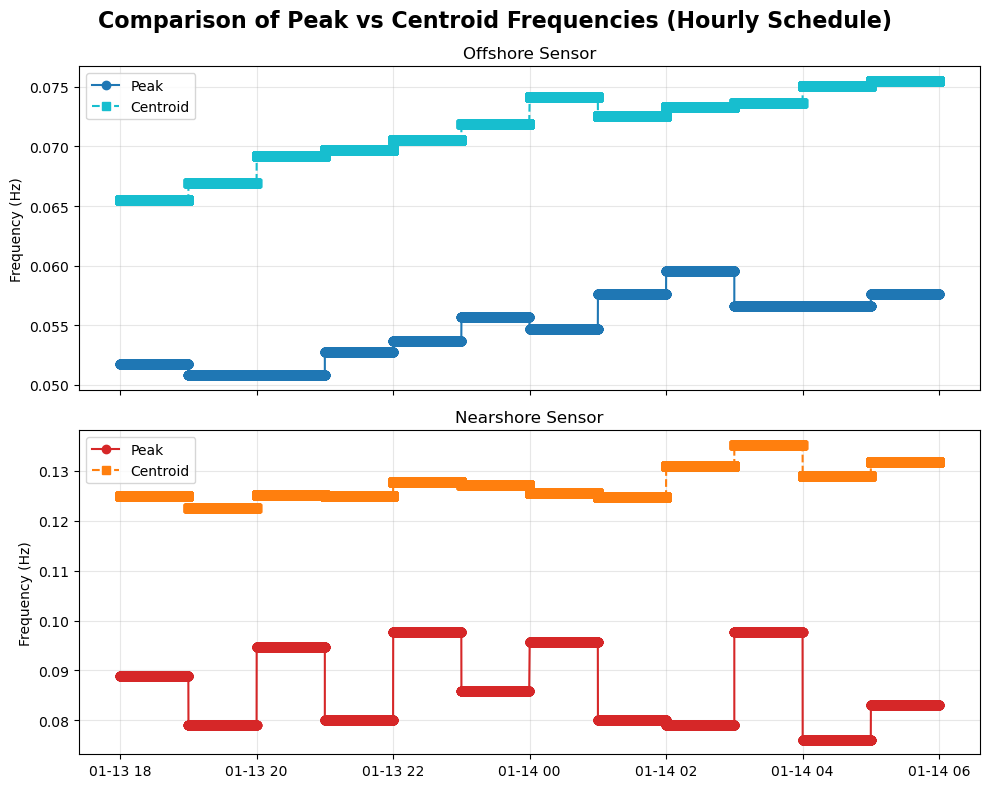

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

plt.suptitle('Comparison of Peak vs Centroid Frequencies (Hourly Schedule)', fontsize=16, fontweight='bold')

# ---- Offshore Frequencies ---- #
axes[0].plot(f0_schedule.index, f0_schedule['Offshore_Peak'], 'o-', label='Peak', color='tab:blue')
axes[0].plot(f0_schedule.index, f0_schedule['Offshore_Centroid'], 's--', label='Centroid', color='tab:cyan')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Offshore Sensor')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Nearshore Frequencies ---- #
axes[1].plot(f0_schedule.index, f0_schedule['Nearshore_Peak'], 'o-', label='Peak', color='tab:red')
axes[1].plot(f0_schedule.index, f0_schedule['Nearshore_Centroid'], 's--', label='Centroid', color='tab:orange')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Nearshore Sensor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Processing 12 hourly blocks...


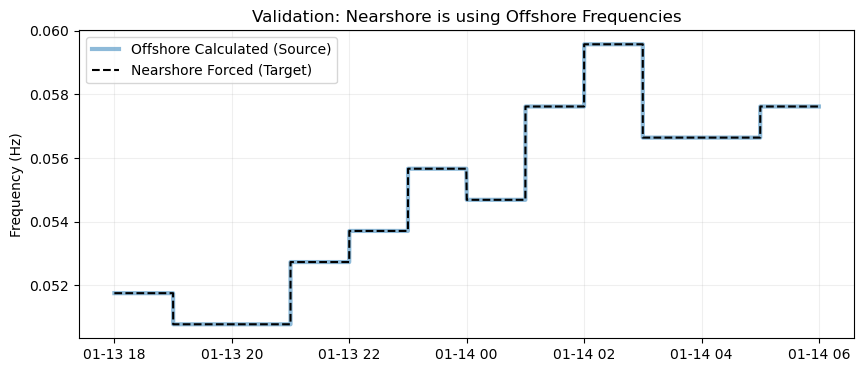

In [15]:
# "Use the Peak frequency of df6 to demodulate df1"
df1_forced = complex_demod_forced(
    df_target=df1, 
    df_source=df6, 
    start=ti, 
    end=tf, 
    f_swell=SS, 
    f0_method='peak' 
)

# calculate the standard df6 demodulation just to compare
df6_standard = complex_demod_hourly(df6, ti, tf, f_swell=SS, f0_method='peak')
plt.figure(figsize=(10, 4))
plt.plot(df6_standard.index, df6_standard['f0'], label='Offshore Calculated (Source)', lw=3, alpha=0.5)
plt.plot(df1_forced.index, df1_forced['f0'], 'k--', label='Nearshore Forced (Target)')
plt.ylabel('Frequency (Hz)')
plt.title('Validation: Nearshore is using Offshore Frequencies')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# ---- Configuration ---- #
ti = pd.Timestamp("2008-01-13 18:00:00")
tf = pd.Timestamp("2008-01-14 06:00:00")
SS = (0.04, 0.20)

# Run the Forced Demodulation
# "Use the Peak frequency of df6 (Offshore) to demodulate df1 (Nearshore)"
df1_forced = complex_demod_forced(
    df_target=df1, 
    df_source=df6, 
    start=ti, 
    end=tf, 
    f_swell=SS, 
    f0_method='peak' 
)

Processing 12 hourly blocks...
                                      A         E        f0
2008-01-13 18:00:00.000000000  0.003612  0.000013  0.051758
2008-01-13 18:00:01.000004608  0.021243  0.000451  0.051758
2008-01-13 18:00:01.999999232  0.038124  0.001453  0.051758
2008-01-13 18:00:03.000003840  0.053636  0.002877  0.051758
2008-01-13 18:00:03.999998208  0.067265  0.004525  0.051758

Verifying frequencies...
Offshore Freq at 18:00: 0.0518 Hz
Nearshore Forced Freq at 18:00: 0.0518 Hz


Running Standard Nearshore Demod...


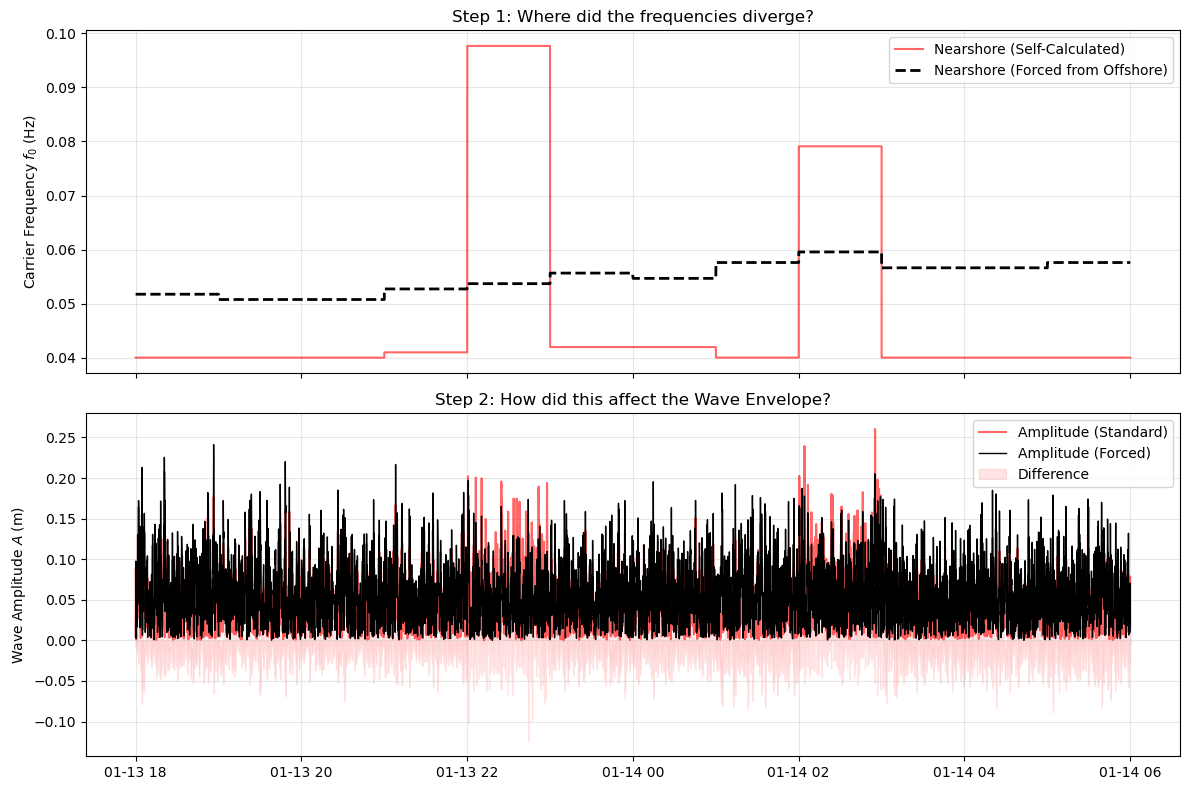

In [10]:
import matplotlib.pyplot as plt

# 1. Run Standard Nearshore Demod (Letting it find its own f0)
print("Running Standard Nearshore Demod...")
df1_standard = complex_demod_hourly(
    df1, ti, tf, p_col="h", f_swell=SS, f0_method='peak'
)

# 2. (You already have df1_forced from the previous step)
# df1_forced = complex_demod_forced(...)

# 3. Plot the comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Panel: The Frequency Divergence
# This shows WHERE the nearshore sensor was "getting confused"
ax1.plot(df1_standard.index, df1_standard['f0'], 'r-', alpha=0.6, label='Nearshore (Self-Calculated)')
ax1.plot(df1_forced.index, df1_forced['f0'], 'k--', lw=2, label='Nearshore (Forced from Offshore)')
ax1.set_ylabel('Carrier Frequency $f_0$ (Hz)')
ax1.set_title('Step 1: Where did the frequencies diverge?')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom Panel: The Amplitude Difference
# This shows the physical impact on your wave height calculations
ax2.plot(df1_standard.index, df1_standard['A'], 'r-', alpha=0.6, label='Amplitude (Standard)')
ax2.plot(df1_forced.index, df1_forced['A'], 'k-', lw=1, label='Amplitude (Forced)')

# Optional: Highlight the difference
# We re-index to ensure alignment (though they should be identical already)
diff = df1_standard['A'] - df1_forced['A']
ax2.fill_between(diff.index, 0, diff, color='red', alpha=0.1, label='Difference')

ax2.set_ylabel('Wave Amplitude $A$ (m)')
ax2.set_title('Step 2: How did this affect the Wave Envelope?')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()